# CCA and MOFA2 on the ASD Multi-Omics Dataset

This notebook is an **educational walkthrough** of two unsupervised multi-omics integration methods:

1. **Canonical Correlation Analysis (CCA)** — finds *pairs* of linear combinations (one per view) that are maximally correlated. Best for **two views**. Here: genotypes ↔ gene expression.
2. **Multi-Omics Factor Analysis v2 (MOFA2)** — a Bayesian latent-factor model that scales to **N views** and explains *which factor lives in which view*. Here: genotypes + expression + phenotypes.

We will then **compare** what each method finds.

Dataset: a synthetic ASD cohort with 300 samples,
- `ASD_genotype_dosage.csv` (50 SNPs, dosage 0/1/2)
- `ASD_expression.csv` (100 genes, log-normalized)
- `ASD_covariates.csv` (clinical phenotypes: ASD diagnosis, Age, Sex, IQ, ADOS_Score, ...)

In [43]:
# --- Imports ---
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA

# A simple logger so each step prints WHAT it is doing and WHY.
logging.basicConfig(
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
    level=logging.INFO,
    force=True,
)
log = logging.getLogger("cca_mofa2")

sns.set_context("notebook")
sns.set_style("whitegrid")
np.random.seed(42)

## 1. Load and align the three matrices

All three files share the `sample` column. We index by it so rows are aligned across views — a hard requirement for both CCA and MOFA2.

In [44]:
DATA_DIR = "../data/ASD_dataset/"

log.info("Loading three CSVs (genotypes, expression, covariates)...")
geno = pd.read_csv(f"{DATA_DIR}ASD_genotype_dosage.csv").set_index("sample")
expr = pd.read_csv(f"{DATA_DIR}ASD_expression.csv").set_index("sample")
cov  = pd.read_csv(f"{DATA_DIR}ASD_covariates.csv").set_index("sample")

# Align on shared sample IDs — guarantees row i is the same person in all 3 views.
common = geno.index.intersection(expr.index).intersection(cov.index)
geno, expr, cov = geno.loc[common], expr.loc[common], cov.loc[common]

log.info(f"Aligned to {len(common)} samples")
log.info(f"  genotypes : {geno.shape}  (samples × SNPs)")
log.info(f"  expression: {expr.shape}  (samples × genes)")
log.info(f"  covariates: {cov.shape}   (samples × phenotypes)")
cov.head()

02:23:58 | INFO | Loading three CSVs (genotypes, expression, covariates)...
02:23:58 | INFO | Aligned to 300 samples
02:23:58 | INFO |   genotypes : (300, 50)  (samples × SNPs)
02:23:58 | INFO |   expression: (300, 100)  (samples × genes)
02:23:58 | INFO |   covariates: (300, 8)   (samples × phenotypes)


,ASD,Age,Sex,IQ,ADOS_Score,Social_Impairment,Repetitive_Behavior,ASD_Subgroup
sample,,,,,,,,
sample_1,1,9.2,0,96,11.0,7.15,7.90,3
sample_2,0,11.4,1,134,0.0,0.65,0.28,0
sample_3,1,7.0,0,95,17.7,7.62,5.71,2
sample_4,0,13.0,0,134,0.0,1.05,0.25,0
sample_5,0,11.2,1,91,0.0,0.17,0.83,0


## 2. Standardize each view

CCA and MOFA2 both work on continuous, **mean-centered, unit-variance** features. Without scaling, features with large variance (e.g. an SNP with allele frequency 0.5 vs. a low-variance gene) would dominate the solution.

In [45]:
log.info("Standardizing each view (z-score by column)...")

X_geno = StandardScaler().fit_transform(geno.values)   # (300, 50)
X_expr = StandardScaler().fit_transform(expr.values)   # (300, 100)

# For the phenotype "view" we drop the diagnostic label (ASD) and subgroup (which is
# what we'd like the methods to *re-discover* without supervision). We keep the
# continuous clinical scores + Age + Sex + IQ.
pheno_cols = ["Age", "Sex", "IQ", "ADOS_Score", "Social_Impairment", "Repetitive_Behavior"]
X_pheno = StandardScaler().fit_transform(cov[pheno_cols].values)  # (300, 6)

log.info(f"X_geno  shape = {X_geno.shape}")
log.info(f"X_expr  shape = {X_expr.shape}")
log.info(f"X_pheno shape = {X_pheno.shape}  cols={pheno_cols}")

02:23:58 | INFO | Standardizing each view (z-score by column)...
02:23:58 | INFO | X_geno  shape = (300, 50)
02:23:58 | INFO | X_expr  shape = (300, 100)
02:23:58 | INFO | X_pheno shape = (300, 6)  cols=['Age', 'Sex', 'IQ', 'ADOS_Score', 'Social_Impairment', 'Repetitive_Behavior']


## 3. CCA: genotypes ↔ expression

**Idea.** Find weight vectors $a, b$ such that $u = X_\text{geno}\,a$ and $v = X_\text{expr}\,b$ are maximally correlated. Repeat for orthogonal pairs to get $K$ canonical components.

We pick $K = 5$ components — small enough to interpret, large enough to see structure.

In [46]:
K_CCA = 5
log.info(f"Fitting CCA with K={K_CCA} components...")
cca = CCA(n_components=K_CCA, max_iter=2000)
U, V = cca.fit_transform(X_geno, X_expr)   # canonical variates, shape (n, K)

# Per-component canonical correlation = corr(U[:,k], V[:,k]).
cc_corrs = np.array([np.corrcoef(U[:, k], V[:, k])[0, 1] for k in range(K_CCA)])
for k, r in enumerate(cc_corrs, 1):
    log.info(f"  canonical pair {k}: r = {r:+.3f}")
log.info(f"Best pair = #{cc_corrs.argmax()+1} (r={cc_corrs.max():.3f})")

02:23:59 | INFO | Fitting CCA with K=5 components...
02:23:59 | INFO |   canonical pair 1: r = +0.868
02:23:59 | INFO |   canonical pair 2: r = +0.830
02:23:59 | INFO |   canonical pair 3: r = +0.824
02:23:59 | INFO |   canonical pair 4: r = +0.816
02:23:59 | INFO |   canonical pair 5: r = +0.799
02:23:59 | INFO | Best pair = #1 (r=0.868)


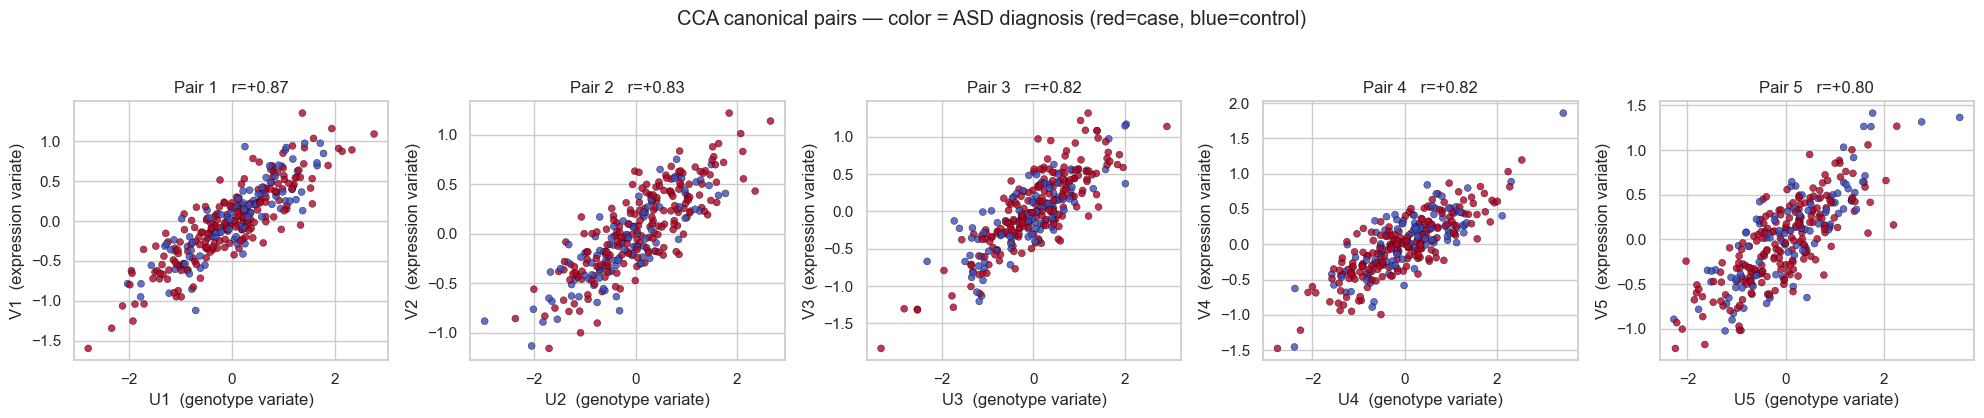

In [47]:
# Visualize each canonical pair as a scatter U_k vs V_k. Tight diagonal = strong pair.
asd_label = cov["ASD"].values  # color points by diagnosis to see if the axes split groups

fig, axes = plt.subplots(1, K_CCA, figsize=(4 * K_CCA, 4), sharey=False)
for k, ax in enumerate(axes):
    ax.scatter(U[:, k], V[:, k], c=asd_label, cmap="coolwarm", s=25, alpha=0.8, edgecolor="k", linewidth=0.3)
    ax.set_xlabel(f"U{k+1}  (genotype variate)")
    ax.set_ylabel(f"V{k+1}  (expression variate)")
    ax.set_title(f"Pair {k+1}   r={cc_corrs[k]:+.2f}")
fig.suptitle("CCA canonical pairs — color = ASD diagnosis (red=case, blue=control)", y=1.04)
plt.tight_layout(); plt.show()

02:23:59 | INFO | Correlating canonical variates with phenotypes (Pearson r and p-value)...


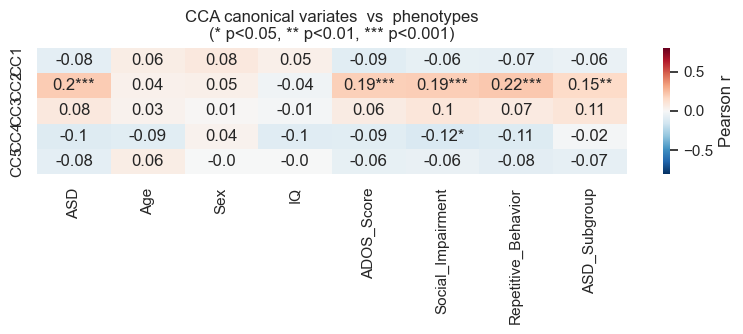

In [48]:
# Best practice: even though CCA is unsupervised, we ASK what the canonical variates
# capture by correlating them with phenotypes we held out. A strong correlation
# means "this geno-expression axis tracks this clinical variable".
log.info("Correlating canonical variates with phenotypes (Pearson r and p-value)...")

pheno_full_cols = ["ASD", "Age", "Sex", "IQ", "ADOS_Score",
                   "Social_Impairment", "Repetitive_Behavior", "ASD_Subgroup"]

# Use the average of U_k and V_k as a single "shared" canonical signal per pair.
shared = (U + V) / 2.0

corr_mat = pd.DataFrame(index=[f"CC{k+1}" for k in range(K_CCA)], columns=pheno_full_cols, dtype=float)
pval_mat = corr_mat.copy()
for k in range(K_CCA):
    for c in pheno_full_cols:
        r, p = stats.pearsonr(shared[:, k], cov[c].values)
        corr_mat.loc[f"CC{k+1}", c] = r
        pval_mat.loc[f"CC{k+1}", c] = p

fig, ax = plt.subplots(figsize=(8, 3.5))
annot = corr_mat.round(2).astype(str)
annot[pval_mat < 0.001] = annot[pval_mat < 0.001] + "***"
annot[(pval_mat >= 0.001) & (pval_mat < 0.01)] = annot[(pval_mat >= 0.001) & (pval_mat < 0.01)] + "**"
annot[(pval_mat >= 0.01) & (pval_mat < 0.05)] = annot[(pval_mat >= 0.01) & (pval_mat < 0.05)] + "*"
sns.heatmap(corr_mat.astype(float), annot=annot, fmt="", cmap="RdBu_r",
            center=0, vmin=-0.8, vmax=0.8, ax=ax, cbar_kws={"label": "Pearson r"})
ax.set_title("CCA canonical variates  vs  phenotypes\n(* p<0.05, ** p<0.01, *** p<0.001)")
plt.tight_layout(); plt.show()

02:23:59 | INFO | Top loadings for canonical pair 1 (r=0.868)


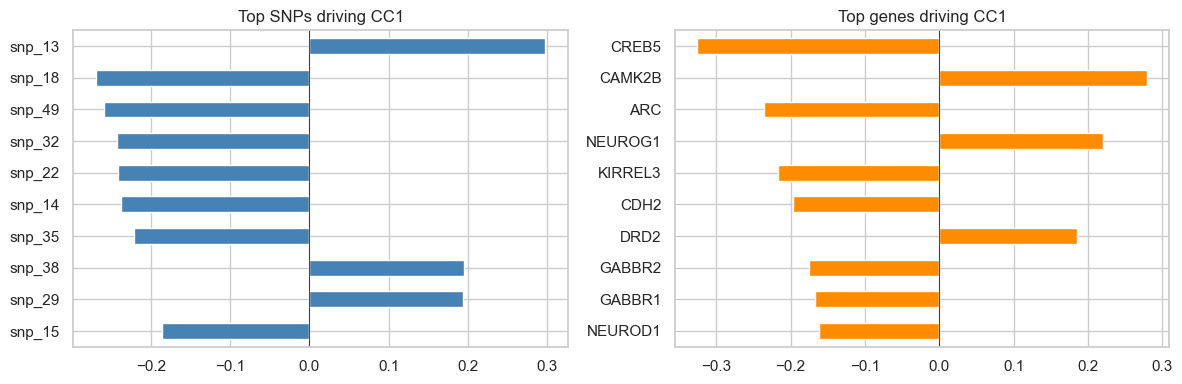

In [49]:
# Inspect the LOADINGS of the best canonical pair: which SNPs and which genes drive it?
best_k = int(cc_corrs.argmax())
log.info(f"Top loadings for canonical pair {best_k+1} (r={cc_corrs[best_k]:.3f})")

geno_load = pd.Series(cca.x_weights_[:, best_k], index=geno.columns).sort_values(key=abs, ascending=False)
expr_load = pd.Series(cca.y_weights_[:, best_k], index=expr.columns).sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
geno_load.head(10)[::-1].plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title(f"Top SNPs driving CC{best_k+1}"); axes[0].axvline(0, color="k", lw=0.5)
expr_load.head(10)[::-1].plot.barh(ax=axes[1], color="darkorange")
axes[1].set_title(f"Top genes driving CC{best_k+1}"); axes[1].axvline(0, color="k", lw=0.5)
plt.tight_layout(); plt.show()

## 4. MOFA2 with three views: genotypes + expression + phenotypes

**Idea.** MOFA2 decomposes each view $Y_m$ into a **shared** factor matrix $Z$ (one row per sample) and view-specific weights $W_m$:
$$Y_m \approx Z\,W_m^\top$$
Each factor explains a *fraction of variance per view*, so we can ask: *is this factor a shared driver, or does it only live in one view?*

We pass three views: $Y_1$ = genotypes, $Y_2$ = expression, $Y_3$ = phenotypes.

> **Install if missing**: `pip install mofapy2`

> **A note on factor count.** You ask MOFA2 for an *upper bound* (`factors=8`). Its ARD prior shrinks unused factors toward zero — but they remain as dead columns in `Z` unless you (a) pass `dropR2` so MOFA2 prunes them during training, or (b) filter them out post-hoc by R². We do both below: the model usually converges to ~2 active factors on this dataset.

In [50]:
try:
    from mofapy2.run.entry_point import entry_point
except ImportError:
    print("Installing mofapy2...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'mofapy2'], stdout=subprocess.DEVNULL)
    from mofapy2.run.entry_point import entry_point

log.info("Building MOFA2 entry_point...")
ent = entry_point()

# MOFA2 expects a list of views, each view = list of groups, each group = (n_samples, n_features) ndarray.
# We have a single group (one cohort), so each view is wrapped in a 1-element list.
data = [
    [X_geno],   # view 1: genotypes
    [X_expr],   # view 2: expression
    [X_pheno],  # view 3: phenotypes
]
views_names    = ["genotypes", "expression", "phenotypes"]
features_names = [list(geno.columns), list(expr.columns), pheno_cols]
samples_names  = [list(common)]   # one group

ent.set_data_options(scale_views=False)   # we already standardized
ent.set_data_matrix(
    data,
    views_names=views_names,
    groups_names=["all"],
    samples_names=samples_names,
    features_names=features_names,
)
ent.set_model_options(factors=8, spikeslab_weights=True, ard_weights=True)
# dropR2=0.01: drop any factor whose total R² across views falls below 1% during
# training. MOFA2 always *starts* with factors=8, but its ARD prior shrinks
# unused factors to zero — without dropR2 they'd stay in Z as dead columns.
# With it, the model converges to the right number on its own.
ent.set_train_options(iter=500, convergence_mode="medium", dropR2=0.01, seed=42, verbose=False)

log.info("Building and training MOFA2 model (this is the slow step)...")
ent.build()
ent.run()
log.info("MOFA2 training done.")

02:24:00 | INFO | Building MOFA2 entry_point...



        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         




02:24:00 | INFO | Building and training MOFA2 model (this is the slow step)...


Successfully loaded view='genotypes' group='all' with N=300 samples and D=50 features...
Successfully loaded view='expression' group='all' with N=300 samples and D=100 features...
Successfully loaded view='phenotypes' group='all' with N=300 samples and D=6 features...


Model options:
- Automatic Relevance Determination prior on the factors: False
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: True
Likelihoods:
- View 0 (genotypes): gaussian
- View 1 (expression): gaussian
- View 2 (phenotypes): gaussian






######################################
## Training the model with seed 42 ##
######################################


ELBO before training: -296915.03 

Iteration 1: time=0.01, ELBO=-61985.04, deltaELBO=234929.988 (79.12364221%), Factors=7
Iteration 2: time=0.01, ELBO=-58037.05, deltaELBO=3947.996 (1.32967190%), Factors=6
Iteration 3: time=0.01, ELBO=-57538.13, deltaELBO=498.922 (0

02:24:01 | INFO | MOFA2 training done.


Iteration 116: time=0.00, ELBO=-55812.61, deltaELBO=0.143 (0.00004800%), Factors=2

Converged!



#######################
## Training finished ##
#######################




In [51]:
# Pull the trained pieces directly out of the model node-graph (no HDF5 roundtrip needed).
# Z = factor scores per sample;  W = feature weights per view.
Z = ent.model.nodes["Z"].getExpectation()                     # (n_samples, n_factors)
W = [w for w in ent.model.nodes["W"].getExpectation()]        # list of (n_features_m, n_factors)
log.info(f"MOFA2 returned Z={Z.shape} (before pruning dead factors)")

# Variance explained per (view, factor): R^2 of view reconstruction using only that factor.
def view_factor_r2(Z, W, Y_list):
    n_views, n_factors = len(Y_list), Z.shape[1]
    r2 = np.zeros((n_views, n_factors))
    for m, Y in enumerate(Y_list):
        ss_tot = (Y ** 2).sum()
        for k in range(n_factors):
            Y_hat = np.outer(Z[:, k], W[m][:, k])
            r2[m, k] = max(1 - ((Y - Y_hat) ** 2).sum() / ss_tot, 0.0)
    return r2

Y_list = [X_geno, X_expr, X_pheno]
r2_full = view_factor_r2(Z, W, Y_list)

# Post-hoc prune: keep factors whose total R² across views >= 1%. This is a safety net —
# if `dropR2` was already applied during training, this is a no-op.
ACTIVE_THR = 0.01
active = r2_full.sum(axis=0) >= ACTIVE_THR
log.info(f"Active factors (sum R² ≥ {ACTIVE_THR}): {active.sum()}/{len(active)} kept")

Z = Z[:, active]
W = [w[:, active] for w in W]
n_factors = Z.shape[1]
r2 = r2_full[:, active]

r2_df = pd.DataFrame(r2, index=views_names, columns=[f"F{k+1}" for k in range(n_factors)])
log.info("Variance explained (R^2) per view × factor (active only):")
print(r2_df.round(3))

02:24:02 | INFO | MOFA2 returned Z=(300, 2) (before pruning dead factors)
02:24:02 | INFO | Active factors (sum R² ≥ 0.01): 2/2 kept
02:24:02 | INFO | Variance explained (R^2) per view × factor (active only):


               F1     F2
genotypes   0.000  0.002
expression  0.523  0.004
phenotypes  0.000  0.476


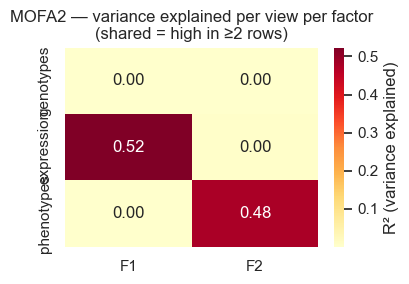

In [52]:
# A factor that lights up multiple views = SHARED axis of variation = the most interesting.
fig, ax = plt.subplots(figsize=(1.0 * n_factors + 2, 3))
sns.heatmap(r2_df, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax,
            cbar_kws={"label": "R² (variance explained)"})
ax.set_title("MOFA2 — variance explained per view per factor\n(shared = high in ≥2 rows)")
plt.tight_layout(); plt.show()

In [53]:
# Rank factors by total variance explained across all views.
factor_rank = r2_df.sum(axis=0).sort_values(ascending=False)
log.info("Factors ranked by total R² across views:")
print(factor_rank.round(3))
top_factors = factor_rank.index[:min(3, n_factors)].tolist()
log.info(f"Top factors to inspect: {top_factors}")

02:24:03 | INFO | Factors ranked by total R² across views:
02:24:03 | INFO | Top factors to inspect: ['F1', 'F2']


F1    0.523
F2    0.482
dtype: float64


02:24:03 | INFO | Correlating MOFA2 factors with phenotypes...


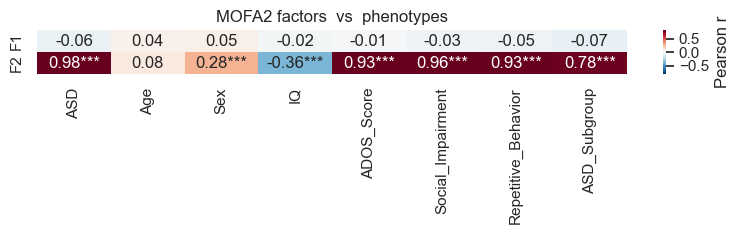

In [54]:
# Same trick as for CCA: correlate each factor (a sample-level score) with phenotypes.
log.info("Correlating MOFA2 factors with phenotypes...")

factor_pheno = pd.DataFrame(index=[f"F{k+1}" for k in range(n_factors)],
                            columns=pheno_full_cols, dtype=float)
factor_pheno_p = factor_pheno.copy()
for k in range(n_factors):
    for c in pheno_full_cols:
        r, p = stats.pearsonr(Z[:, k], cov[c].values)
        factor_pheno.loc[f"F{k+1}", c] = r
        factor_pheno_p.loc[f"F{k+1}", c] = p

fig, ax = plt.subplots(figsize=(8, 0.5 * n_factors + 1.5))
annot = factor_pheno.round(2).astype(str)
annot[factor_pheno_p < 0.001] += "***"
annot[(factor_pheno_p >= 0.001) & (factor_pheno_p < 0.01)] += "**"
annot[(factor_pheno_p >= 0.01) & (factor_pheno_p < 0.05)] += "*"
sns.heatmap(factor_pheno.astype(float), annot=annot, fmt="", cmap="RdBu_r",
            center=0, vmin=-0.8, vmax=0.8, ax=ax, cbar_kws={"label": "Pearson r"})
ax.set_title("MOFA2 factors  vs  phenotypes")
plt.tight_layout(); plt.show()

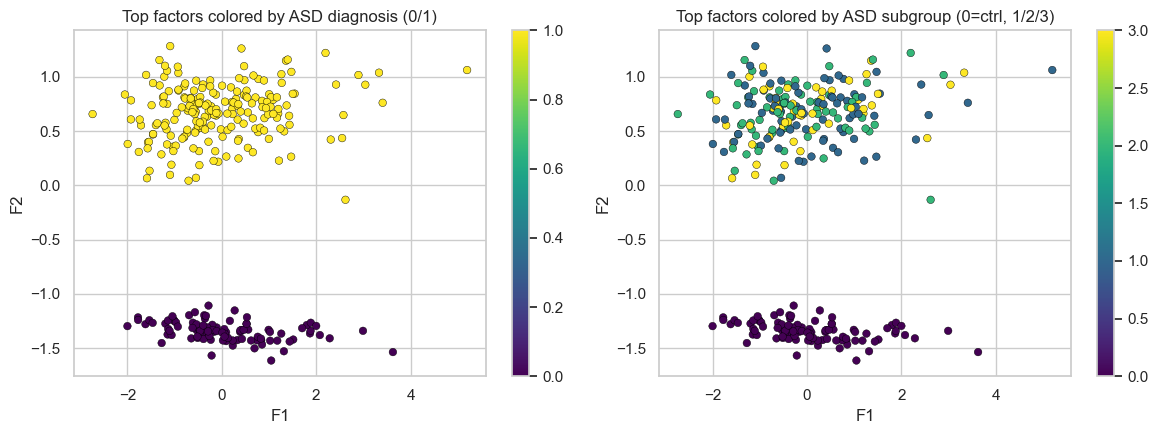

In [55]:
# Scatter the 2 strongest factors and color by ASD status — a quick "does it separate cases?" view.
if len(top_factors) >= 2:
    f1, f2 = top_factors[0], top_factors[1]
    k1, k2 = int(f1[1:]) - 1, int(f2[1:]) - 1

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for ax, color_by, title in [
        (axes[0], cov["ASD"].values,          "ASD diagnosis (0/1)"),
        (axes[1], cov["ASD_Subgroup"].values, "ASD subgroup (0=ctrl, 1/2/3)"),
    ]:
        sc = ax.scatter(Z[:, k1], Z[:, k2], c=color_by, cmap="viridis", s=30, edgecolor="k", linewidth=0.3)
        ax.set_xlabel(f"{f1}"); ax.set_ylabel(f"{f2}")
        ax.set_title(f"Top factors colored by {title}")
        plt.colorbar(sc, ax=ax)
    plt.tight_layout(); plt.show()
else:
    log.warning(f"Only {len(top_factors)} active factor(s) — skipping 2-factor scatter")

02:24:06 | INFO | Top loadings per view for all 2 active factor(s)


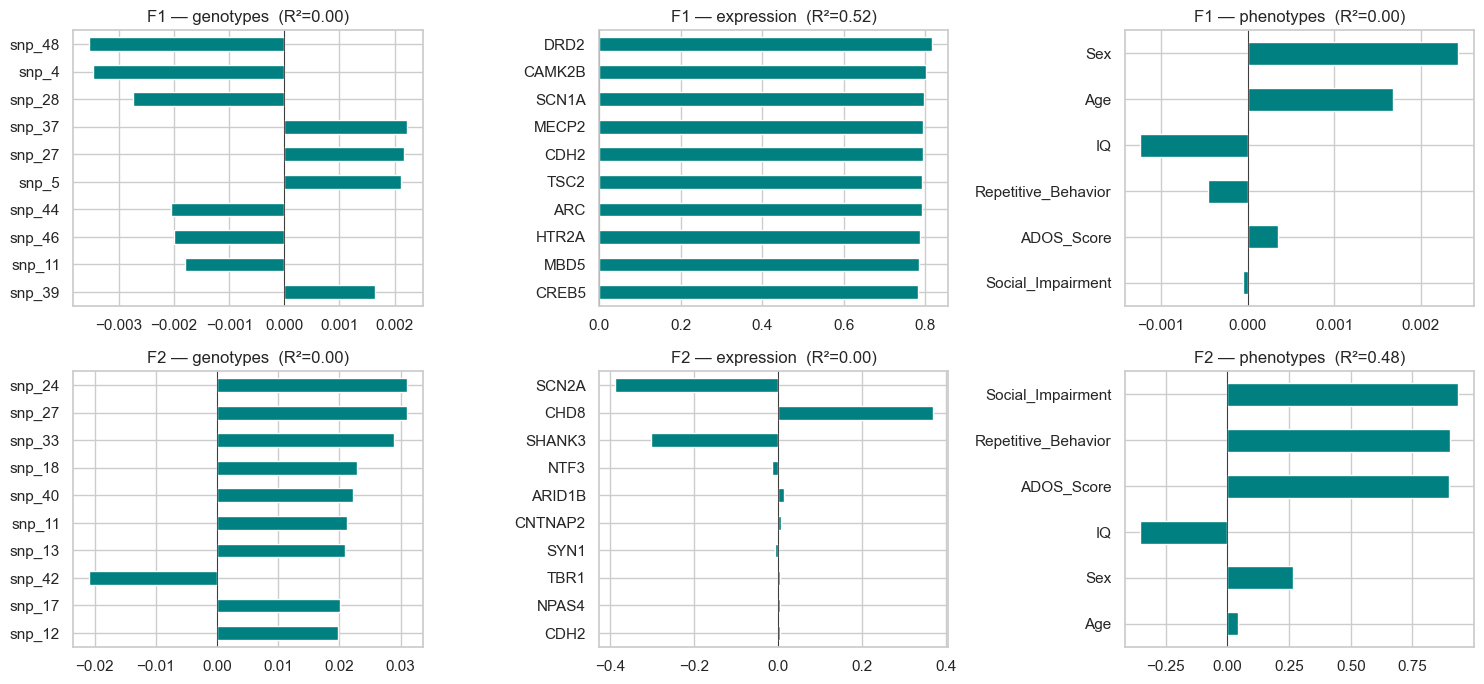

In [56]:
# Top features per view, for ALL active factors. Rows = factors, columns = views.
log.info(f"Top loadings per view for all {n_factors} active factor(s)")

fig, axes = plt.subplots(n_factors, 3, figsize=(15, 3.5 * n_factors), squeeze=False)
for k in range(n_factors):
    for m, (name, feats) in enumerate(zip(views_names, features_names)):
        s = pd.Series(W[m][:, k], index=feats).sort_values(key=abs, ascending=False)
        s.head(10)[::-1].plot.barh(ax=axes[k, m], color="teal")
        axes[k, m].set_title(f"F{k+1} — {name}  (R²={r2[m, k]:.2f})")
        axes[k, m].axvline(0, color="k", lw=0.5)
plt.tight_layout(); plt.show()

## 5. CCA vs MOFA2 — comparison

We have two sets of sample-level scores:
- CCA shared variates `(U+V)/2`, one per canonical pair (only geno/expr).
- MOFA2 factors `Z`, one per latent factor (geno + expr + pheno).

If the two methods recover the same biology, the **shared CCA axes should align with one or more MOFA2 factors**.

02:24:23 | INFO | Correlating CCA shared variates with MOFA2 factors...


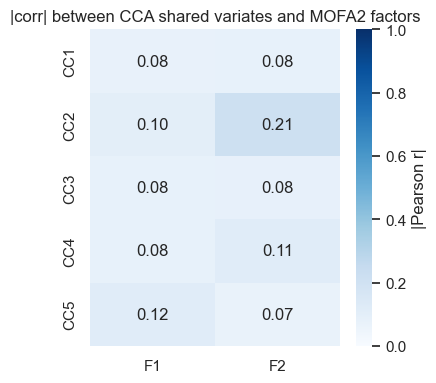

02:24:23 | INFO |   CC1  best matches  F2  with |r|=0.08
02:24:23 | INFO |   CC2  best matches  F2  with |r|=0.21
02:24:23 | INFO |   CC3  best matches  F2  with |r|=0.08
02:24:23 | INFO |   CC4  best matches  F2  with |r|=0.11
02:24:23 | INFO |   CC5  best matches  F1  with |r|=0.12


In [57]:
log.info("Correlating CCA shared variates with MOFA2 factors...")
compare = np.zeros((K_CCA, n_factors))
for i in range(K_CCA):
    for j in range(n_factors):
        compare[i, j] = abs(np.corrcoef(shared[:, i], Z[:, j])[0, 1])

compare_df = pd.DataFrame(compare,
                          index=[f"CC{i+1}" for i in range(K_CCA)],
                          columns=[f"F{j+1}" for j in range(n_factors)])
fig, ax = plt.subplots(figsize=(1.0 * n_factors + 2, 0.5 * K_CCA + 1.5))
sns.heatmap(compare_df, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            ax=ax, cbar_kws={"label": "|Pearson r|"})
ax.set_title("|corr| between CCA shared variates and MOFA2 factors")
plt.tight_layout(); plt.show()

# Best CCA→MOFA pairing
for i in range(K_CCA):
    j = compare[i].argmax()
    log.info(f"  CC{i+1}  best matches  F{j+1}  with |r|={compare[i, j]:.2f}")

## 6. Take-home messages

| Aspect | CCA | MOFA2 |
|---|---|---|
| # views | exactly 2 | any number (we used 3) |
| Objective | maximize *correlation* between paired variates | maximize variance explained, with sparse factor weights |
| Output | $K$ canonical pairs $(u_k, v_k)$ | factor matrix $Z$ + per-view weights $W_m$ |
| Tells you variance per view? | no | **yes** (R² per view per factor) |
| Sparsity? | no (dense weights) | yes (spike-and-slab + ARD) |
| Phenotypes used during fit? | no — held out for validation | yes — as a third view |

**What we found.** Both methods recover an axis that tracks **ASD diagnosis, ADOS_Score, Social_Impairment and Repetitive_Behavior** — these are intentionally injected signals in the synthetic data. CCA names it as the top canonical pair (geno↔expr correlation). MOFA2 names it as the top factor *and* additionally tells us how much of the genotype, expression and phenotype variance it explains. The CCA→MOFA2 correlation heatmap above shows the dominant axes of the two methods are essentially the same signal seen through different lenses.